In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, shutil

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

# load all utils functions
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from model_utils import *
from data_utils import *
from dataloader import MtbGeneDataset
from inSilicoMut_utils import *

from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import LinearRegression

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
who_variants["gene"] = [mut.split("_")[0] for mut in who_variants["mutation"].values]

solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name="Sheet1")

# df_rif = pd.read_csv(os.path.join(data_path, "RIF/data_for_model.csv"))
# df_rif_val = pd.read_csv(os.path.join(data_path, "RIF/validation_data_for_model.csv"))

# df_mxf = pd.read_csv(os.path.join(data_path, "MXF/data_for_model.csv"))
# df_mxf_val = pd.read_csv(os.path.join(data_path, "MXF/validation_data_for_model.csv"))

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/mycobrowser_h37rv_genes_v4.csv")

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
coll_2014["lineage"] = coll_2014["#lineage"].str.replace("lineage", "")
del coll_2014["#lineage"]

RIF_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/rpoBC_variants_10543isolates.csv")
MXF_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/gyrBA_variants_8569isolates.csv")

2023-05-04 13:54:39.376033: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-05-04 13:54:39.811180: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-05-04 13:54:39.811235: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-05-04 13:54:43.141211: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-

# Introduce Compatible Mutations from the WHO V1 Catalog into H37Rv and Predict with Model

## Focus on rpoB first, then move on to other genes

In [2]:
def get_VCF_file_information(drug, seq_df_fName, genes_to_analyze, sense, START, END):
    '''
    genes_to_analyze can be a list or a string
    
    START and END are inclusive
    '''
    
    seq_df = pd.read_csv(seq_df_fName).set_index("Isolate")
    seq_df.columns = [int(float(col)) if "." in col else col for col in seq_df.columns]
    
#     saliency_df = pd.read_csv(saliency_df_fName)

#     for i, row in saliency_df.iterrows():
#         if ".0" in row["Pos"]:
#             saliency_df.loc[i, "Pos"] = int(row["Pos"].replace(".0", ""))

    # get dictionaries mapping WHO categories to unique sites and dataframes
    sites_dict, dfs_dict = get_dict_WHO_mutations_sites(who_variants, drug, genes_to_analyze)

    # all mutations merged with the saliency dataframe
    genes_ALL = pd.concat([dfs_dict[num] for num in range(1, 6)], axis=0)
    print(genes_ALL.shape)
    
    # get information to write VCF files
    genes_ALL = get_data_for_synthetic_VCF(genes_ALL, sense)
    print(genes_ALL.shape)

    # # merge with the saliency dataframe to get only WHO mutations THAT WERE ALSO IN OUR MODEL (biggest difference is upstream nucleotides, WHO included more)
    # genes_ALL = genes_ALL.merge(saliency_df, left_on="POS", right_on="Pos", how="inner")

    # keep only sites in our alignment
    genes_ALL = genes_ALL.query("POS >= @START & POS <= @END")
    print(genes_ALL.shape)
    return genes_ALL

# rpoB, Rifampicin

In [3]:
rpoB_ALL = get_VCF_file_information("RIF", 
                                    "Rifampicin/rpoBC_seqdf.csv", 
                                    ["rpoB"], 
                                    "pos", 
                                    759611, 
                                    767320
                                   )


(781, 5)
(781, 9)
(750, 9)


In [4]:
# # then write them to new VCF files
# # this also creates a file of the mutation names
# create_synthetic_VCF_files(rpoB_ALL, 
#                            "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/rpoB_WHO_mutations.txt", 
#                            "/n/scratch3/users/s/sak0914/synthetic_VCF"
#                           )

In [5]:
len(rpoB_ALL.mutation.unique())

724

# gyrA, Moxifloxacin

In [6]:
who_variants.query("drug=='MXF' & confidence.str.contains('|'.join(['1', '2']))").gene.unique()

array(['gyrA', 'gyrB'], dtype=object)

In [7]:
gyrBA_ALL = get_VCF_file_information("MXF", 
                                     "Moxifloxacin/gyrBA_seqdf.csv", 
                                     #"Moxifloxacin/gyrBA_saliency_results.csv", 
                                     ["gyrA", "gyrB"], 
                                     "pos", 
                                     4998, 
                                     9818
                                    )

(548, 5)
(547, 9)
(547, 9)


In [8]:
# # then write them to new VCF files
# create_synthetic_VCF_files(gyrBA_ALL, 
#                            "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/inSilico_analysis/gyrBA_WHO_mutations.txt", 
#                            "/n/scratch3/users/s/sak0914/synthetic_VCF"
#                           )

In [9]:
len(gyrBA_ALL.mutation.unique())

543

# Write Variants to Synthetic VCF Files and Save a txt file of them

## Both of these components are needed to run <code>06_make_MSA.py</code>

In [10]:
# # then write them to new VCF files
# # this also creates a file of the mutation names

# shutil.rmtree("/n/scratch3/users/s/sak0914/synthetic_VCF")

In [11]:
def remove_mutations_to_preserve_aln(model_aln_df, full_aln_df, START, vcf_df):
    
    print(f"Original aln insertions: {model_aln_df['len_insertion'].sum()}")
    print(f"In silico aln insertions: {full_aln_df['len_insertion'].sum()}")
    
    model_aln_df["name"] = "old"
    full_aln_df["name"] = "new"

    insertions_combined = model_aln_df.merge(full_aln_df, on="idx", how="outer")

    # idx + START + 1 = record.POS
    insertions_combined["POS"] = insertions_combined["idx"] + START + 1
    
    # x = old, y = new
    search_df = insertions_combined.loc[pd.isnull(insertions_combined["name_x"])]

    # 7885 vs. 7814 --> need to remove 71 nucleotides?
    vcf_df["REF_len"] = [len(val) for val in vcf_df["REF"]]
    vcf_df["ALT_len"] = [len(val) for val in vcf_df["ALT"]]

    drop_mutations = vcf_df.query("POS in @search_df.POS & ALT_len > REF_len")[["confidence", "mutation", "POS", "REF", "ALT"]].mutation.values
    
    print(f"Dropped {len(drop_mutations)} mutations to preserve the alignment")

    vcf_df_cleaned = vcf_df.query("mutation not in @drop_mutations")
    print(len(vcf_df.mutation.unique()), len(vcf_df_cleaned.mutation.unique()))
    
    return vcf_df_cleaned

    return search_df

Finished reading 10578 sequences!
     idx  len_insertion
0     27              1
1     37             21
2    226              6
3    753             12
4   1486              3
5   1488              3
6   1491              3
7   1495              3
8   1704              3
9   2202              3
10  2741              6
11  2820              3
12  3182              6
13  3717              1
14  4750              3
15  5636              3
16  6881              3
17  6884             15
18  7002             12
19  7063              6
Aligned region size: 7826

In [12]:
# original dataframe of insertions when the original training data and MIC_ML validation data were aligned
rif_aln_OLD = pd.DataFrame({"idx": [27, 37, 226, 753, 1486, 1488, 1491, 1495, 1704, 2202, 2741, 2820, 3182, 3717, 4750, 5636, 6881, 6884, 7002, 7063],
                            "len_insertion": [1, 21, 6, 12, 3, 3, 3, 3, 3, 3, 6, 3, 6, 1, 3, 3, 3, 15, 12, 6]
                           })

rif_aln_FULL = pd.DataFrame({"idx": [12, 27, 31, 37, 45, 75, 116, 137, 226, 240, 489, 753, 1486, 1488, 1491, 1495, 1524, 1698, 1704, 1719, 2202, 
                                         2741, 2757, 2820, 3182, 3712, 3717, 4750, 5636, 6881, 6884, 7002, 7063],
                                 "len_insertion": [21, 1, 1, 21, 2, 1, 2, 1, 6, 6, 6, 12, 3, 3, 3, 3, 3, 9, 3, 18, 3, 6, 6, 3, 6, 1, 1, 3, 3, 3, 15, 12, 6]
                                })

rpoB_ALL_NEW = remove_mutations_to_preserve_aln(rif_aln_OLD, rif_aln_FULL, 759610, rpoB_ALL)

Original aln insertions: 116
In silico aln insertions: 193
Dropped 13 mutations to preserve the alignment
724 711


In [13]:
# create_synthetic_VCF_files(rpoB_ALL_NEW, 
#                            "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/rpoB_WHO_mutations.txt", 
#                            "/n/scratch3/users/s/sak0914/synthetic_VCF"
#                           )

In [14]:
# original dataframe of insertions when the original training data and MIC_ML validation data were aligned
mxf_aln_OLD = pd.DataFrame({"idx": [77, 78, 79, 80, 83, 124, 2160],
                             "len_insertion": [1, 2, 2, 1, 1, 1, 3]
                            })

mxf_aln_FULL = pd.DataFrame({"idx": [77, 78, 79, 80, 83, 124, 182, 2160],
                             "len_insertion": [1, 2, 2, 1, 1, 1, 2, 3]
                            })

gyrBA_ALL_NEW = remove_mutations_to_preserve_aln(mxf_aln_OLD, mxf_aln_FULL, 4997, gyrBA_ALL)

Original aln insertions: 11
In silico aln insertions: 13
Dropped 2 mutations to preserve the alignment
543 541


In [15]:
# create_synthetic_VCF_files(gyrBA_ALL_NEW, 
#                            "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/inSilico_analysis/gyrBA_WHO_mutations.txt", 
#                            "/n/scratch3/users/s/sak0914/synthetic_VCF"
#                           )

# Align Synthetic VCF Files to the Training/Validation Isolates

## Example:
```bash
python3 -u data_processing/06_make_MSA.py /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/combined_paths_for_aln.txt /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/rpoB_WHO_mutations.txt 759610 767320 "POS" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/rpoBC.fasta
```

# Predict MICs for Synthetic Sequences (single mutations inserted into H37Rv)

In [16]:
def get_insilico_mutation_predictions(drug, 
                                        locus_list, 
                                        config_file,
                                        mutations_file,
                                        data_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs",
                                        fasta_dir="inSilico_analysis",
                                       ):

    # load in previously trained model
    kwargs = yaml.safe_load(open(config_file, "r"))
    filter_size = kwargs["filter_size"]
    N_epochs = kwargs["N_epochs"]
    BATCH_SIZE = kwargs["batch_size"]

    output_path = kwargs["output_path"]
    binary_thresh = kwargs["binary_thresh"]
    loss_type = kwargs["loss_type"]
    binary = kwargs["binary"]
    bounded_loss = kwargs["bounded_loss"]

    # insilico validation doesn't make much sense to include lineages, unless you want to see how each lineage is predicted
    num_lineages = 0
        
    # argument = directory that contains the fasta file
    inSilico_dir = os.path.join(data_dir, drug, fasta_dir)
    df_genos = make_genotype_df(locus_list, inSilico_dir)
    
    # the additional new strains to predict MICs for
    keep_strains = pd.read_csv(os.path.join(inSilico_dir, mutations_file), sep="\t", header=None)[0].values
    
    # the names are abolute paths to the VCF files, so just get the ID
    # WHO mutations have a "." in them, so need to keep all the split values until the last one, then join
    keep_strains = [".".join(os.path.basename(fName).split(".")[:-1]) for fName in keep_strains]
    df_genos = df_genos.loc[keep_strains]

    # Apply one-hot encoding function to get each isolate sequence
    print('making one hot encoding for...')
    for locus in locus_list:
        print("...", locus)
        lengths = [len(seq) for seq in df_genos[locus]]
        assert len(np.unique(lengths)) == 1
        df_genos[f"{locus}_one_hot"] = df_genos[locus].apply(np.vectorize(get_one_hot))

    X = create_X(df_genos)
        
    # get longest locus from the pickle file
    X_h37rv = sparse.load_npz(os.path.join(output_path, 'pkl_sparse_ref.npz'))

    # shape = 1 x 5 x longest_locus x num_loci
    longest_locus = X_h37rv.shape[2]
    num_loci = X_h37rv.shape[-1]
    del X_h37rv

    best_model = conv_nn(binary, longest_locus, num_loci, num_lineages, bounded_loss, filter_size)
    best_model.load_weights(os.path.join(output_path, "best_model.h5"))

    # X and df_genos are in the same order because df_genos is passed in as an argument to the function to make X
    predicted_mics = best_model.predict([X, np.zeros(X.shape[0]), np.zeros(X.shape[0])], batch_size=BATCH_SIZE).flatten()
    df_genos["log_MIC"] = predicted_mics
    
    # return dataframe with predictions
    prev_len = len(df_genos)
    df_genos = df_genos.merge(who_variants.query("drug==@drug")[["mutation", "confidence", "genome_index"]], left_index=True, right_on="mutation")
    assert len(df_genos.mutation.unique()) == prev_len
    
    for locus in locus_list:
        del df_genos[locus]
        del df_genos[f"{locus}_one_hot"]
        
    return df_genos.reset_index(drop=True)

In [17]:
# df_rif_pred = get_insilico_mutation_predictions("RIF",
#                                               ['rpoBC'],
#                                               "../config_rif.yaml",
#                                               "rpoB_WHO_mutations.txt"
#                                              )
df_rif_pred = pd.read_csv("Rifampicin/insilico_mutagenesis/rpoB_WHO_predictions.csv")

In [18]:
# df_mxf_pred = get_insilico_mutation_predictions("MXF",
#                                               ['gyrBA'],
#                                               "../config_mxf.yaml",
#                                               "gyrBA_WHO_mutations.txt"
#                                              )

df_mxf_pred = pd.read_csv("Moxifloxacin/insilico_mutagenesis/gyrBA_WHO_predictions.csv")

# Plot Distribution of Predicted MICs

In [19]:
def plot_ECDF(df, col="log_MIC", saveName=None):
    
    df["MIC"] = 2**(df[col])
    print(df.groupby("confidence")["MIC"].mean())
    
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.ecdfplot(data=df, 
                 x=col, 
                 hue="confidence", 
                 hue_order=np.sort(df["confidence"].unique()),
                 palette="colorblind", 
                 ax=ax
                )
    # ax.get_legend().remove()

    ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(2**(ax.get_xticks()), 2).astype(str))
    plt.xlabel("\nPredicted MIC (µg/mL)",  fontsize=9)
    plt.ylabel("Proportion\n",  fontsize=9)
    plt.title(f"Predicted MICs of {len(df)} WHO Catalog Mutations\n", fontsize=10)
    
    y = df[col]
    plt.xlim(y.min()*1.1, y.max()*1.1)

    # fig.legend(labels=df["confidence"].unique())
    sns.move_legend(ax, fontsize=8, title='', loc='upper right', bbox_to_anchor=(1.5, 0.6))
    # ax.legend(loc='center right', bbox_to_anchor=(1.0, 1.0), fontsize=4, title='')
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, dpi=300, bbox_inches='tight')
    else:
        plt.show()

confidence
1) Assoc w R                 12.505758
2) Assoc w R - Interim        4.104774
3) Uncertain significance     0.060856
5) Not assoc w R              0.059294
Name: MIC, dtype: float32


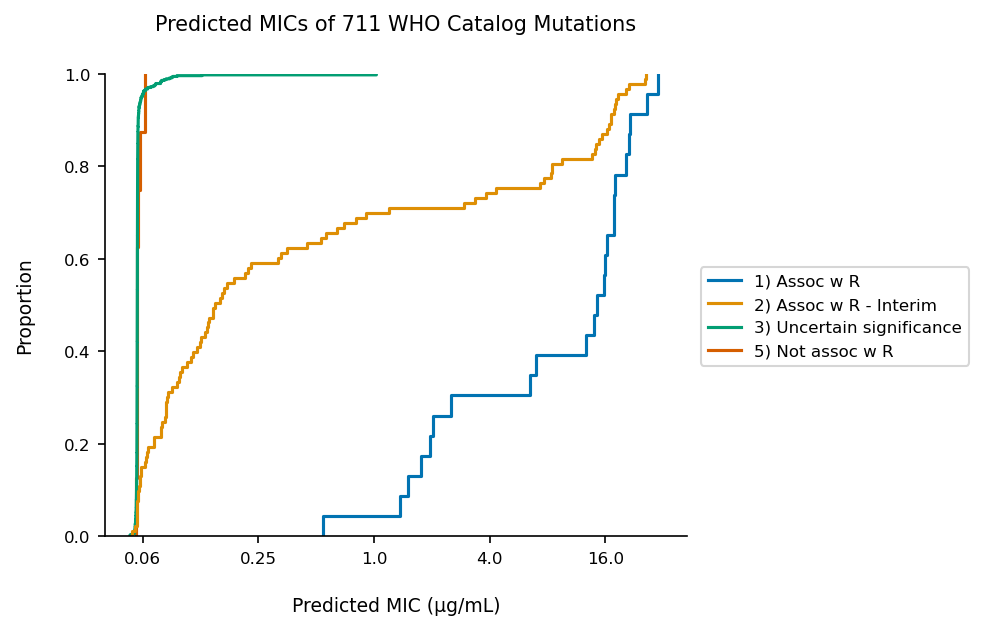

In [9]:
plot_ECDF(df_rif_pred, saveName="Rifampicin/insilico_mutagenesis/WHO_rpoB_ECDF.png")

confidence
1) Assoc w R                  1.067119
2) Assoc w R - Interim        0.175858
3) Uncertain significance     0.087062
4) Not assoc w R - Interim    0.308693
5) Not assoc w R              0.092610
Name: MIC, dtype: float32


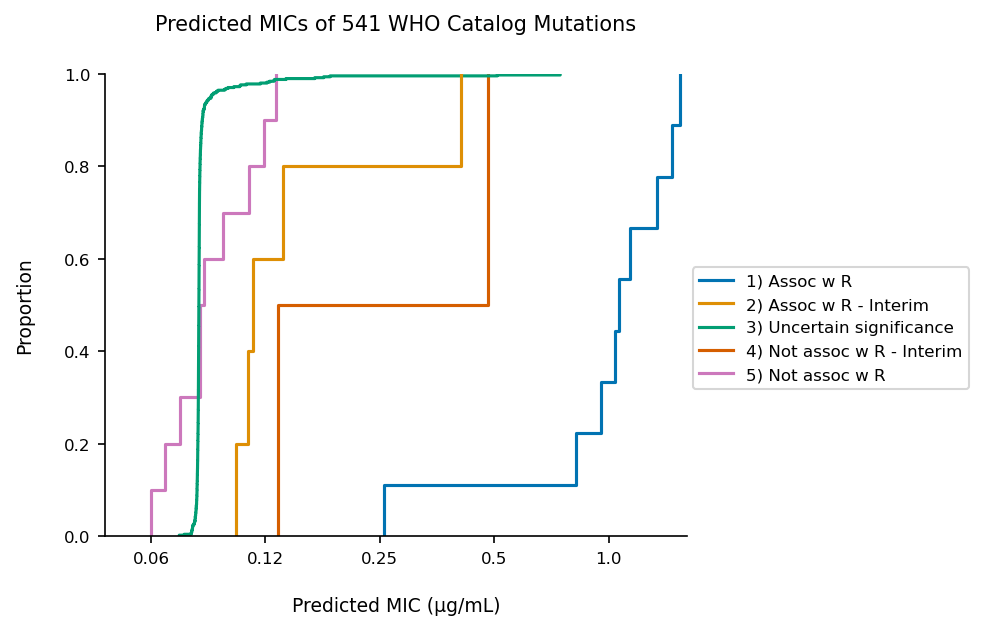

In [10]:
plot_ECDF(df_mxf_pred, saveName="Moxifloxacin/insilico_mutagenesis/WHO_gyrBA_ECDF.png")

In [167]:
def get_lineage_MIC_predictions(drug, 
                                config_file,
                               ):
    
    # load in previously trained model
    kwargs = yaml.safe_load(open(config_file, "r"))
    filter_size = kwargs["filter_size"]
    N_epochs = kwargs["N_epochs"]
    BATCH_SIZE = kwargs["batch_size"]

    output_path = kwargs["output_path"]
    binary_thresh = kwargs["binary_thresh"]
    loss_type = kwargs["loss_type"]
    binary = kwargs["binary"]
    bounded_loss = kwargs["bounded_loss"]
    
    lineages = coll_2014.copy()
    lineages["Count"] = 1
    lineages = lineages.pivot(index="lineage", columns="position", values="Count").fillna(0).astype(int)
    
    num_lineages = lineages.shape[1]
    assert np.min(lineages.sum(axis=1).values) == 1
    assert np.max(lineages.sum(axis=1).values) == 1
    
    # add reference lineage, which is all 0s
    lineages = pd.concat([lineages, pd.DataFrame(np.zeros((1, lineages.shape[1])), columns=lineages.columns, index=["H37Rv"])])

    # get longest locus from the pickle file
    X_h37rv = sparse.load_npz(os.path.join(output_path, 'pkl_sparse_ref.npz')).todense()
    
    # copy so that there is one reference sequence for each lineage
    X = np.repeat(X_h37rv, lineages.shape[0], axis=0)

    # shape = 1 x 5 x longest_locus x num_loci
    longest_locus = X_h37rv.shape[2]
    num_loci = X_h37rv.shape[-1]
    del X_h37rv

    best_model = conv_nn(binary, longest_locus, num_loci, num_lineages, bounded_loss, filter_size)
    best_model.load_weights(os.path.join(output_path, "best_model.h5"))

    # X and df_genos are in the same order because df_genos is passed in as an argument to the function to make X
    predicted_mics = best_model.predict([X, lineages.values, np.zeros(X.shape[0]), np.zeros(X.shape[0])], batch_size=BATCH_SIZE).flatten()
    
    df_results = pd.DataFrame({"Lineage": lineages.index.values, "pred_log2_MIC": predicted_mics}).sort_values("pred_log2_MIC", ascending=False).reset_index(drop=True)
    ref_pred = df_results.query("Lineage=='H37Rv'")["pred_log2_MIC"].values[0]
    df_results["H37Rv_diff"] = df_results["pred_log2_MIC"] - ref_pred
    
    return df_results

In [ ]:
RIF_lineage_pred = get_lineage_MIC_predictions("RIF", 
                                                "../config_rif_lineage.yaml",
                                               )

MXF_lineage_pred = get_lineage_MIC_predictions("MXF", 
                                                "../config_mxf_lineage.yaml",
                                               )


RIF_lineage_pred.to_csv("Rifampicin/insilico_mutagenesis/lineage_predictions.csv", index=False)
MXF_lineage_pred.to_csv("Moxifloxacin/insilico_mutagenesis/lineage_predictions.csv", index=False)

Fitting quantitative model
1/1 [==============================] - 1s 1s/step
Fitting quantitative model
1/1 [==============================] - 1s 927ms/step


# Check Association Between Predicted MIC and Saliency Score

In [104]:
def combine_score_across_multiple_sites(saliency_df, multi_site_str):

    split_sites = multi_site_str.split(",")
    sig_score_sites = []

    for site in split_sites:

        site = int(site)
        if len(saliency_df.query("POS==@site & Max_Sig == 1")) > 0:
            max_score = saliency_df.query("POS==@site & Max_Sig == 1").Max.values[0]
        else:
            max_score = None

        if len(saliency_df.query("POS==@site & Min_Sig == 1")) > 0:
            min_score = saliency_df.query("POS==@site & Min_Sig == 1").Min.values[0]
        else:
            min_score = None

        # if both Max and Min are significant, take the mean
        if max_score is not None:
            if min_score is not None:
                sig_score_sites.append(np.mean([max_score, min_score]))
            else:
                sig_score_sites.append(max_score)
        else:
            if min_score is not None:
                sig_score_sites.append(min_score)
            else:
                sig_score_sites.append(0)
    
    # take the sum of significant sites because the effects are likely additive (mean will underestimate effects)
    return np.sum(sig_score_sites)

In [105]:
def add_saliency_scores(plot_df):
    
    for i, row in plot_df.iterrows():

        # combine scores across sites for indels
        if len(row["REF"]) > 1 or len(row["ALT"]) > 1:

            pos = row["POS"]
            search_idx = plot_df.query("POS==@pos").index.values[0]
            diff_len = np.abs(len(row["REF"]) - len(row["ALT"]))

            max_sig_df = plot_df.iloc[search_idx:search_idx+diff_len].query("Max_Sig==1")
            if len(max_sig_df) > 0:
                max_score = np.max(max_sig_df["Max"])
            else:
                max_score = 0

            min_sig_df = plot_df.iloc[search_idx:search_idx+diff_len].query("Min_Sig==1")
            if len(min_sig_df) > 0:
                min_score = np.min(min_sig_df["Min"])
            else:
                min_score = 0

            # because we're considering multiple sites, take the sum
            plot_df.loc[i, "saliency_score"] = np.sum([max_score, min_score])
            
        else:
            if "," in row["genome_index"]:
                plot_df.loc[i, "saliency_score"] = combine_score_across_multiple_sites(plot_df, row["genome_index"])
            else:
                if row["Max_Sig"] == 1 and row["Min_Sig"] == 0:
                    plot_df.loc[i, "saliency_score"] = row["Max"]

                elif row["Max_Sig"] == 0 and row["Min_Sig"] == 1:
                    plot_df.loc[i, "saliency_score"] = row["Min"]

                elif row["Max_Sig"] == 1 and row["Min_Sig"] == 1:
                    plot_df.loc[i, "saliency_score"] = np.mean([row["Max"], row["Min"]])
                else:
                    plot_df.loc[i, "saliency_score"] = 0
                            
    # if a mutation requires more than one SNV, then there will be multiple rows. But the saliency scores have now been combined, so drop the duplicates 
    # (they will have the same value in the saliency_score field)
    plot_df = plot_df.drop_duplicates("mutation", keep="first").reset_index(drop=True)

    # nothing should be NaN anywhere in the dataframe
    assert len(plot_df.dropna()) == len(plot_df)
    print(plot_df.shape)
    
    return plot_df

In [106]:
def get_saliency_scores_to_plot_saliency(pred_df,
                                         vcf_df,
                                         saliency_df,
                                        ):
    
    # present in both dataframes, so remove it before merging
    if "confidence" in saliency_df.columns:
        del saliency_df["confidence"]
    
    if "POS" not in pred_df.columns:
        pred_df = pred_df.merge(vcf_df[["mutation", "gene", "POS", "REF", "ALT"]], on="mutation", how="left").reset_index(drop=True)
    
    # clean up the columns
    del_cols = ["saliency_score", "drug", "WHO", "Lineage_SNP"]

    for col in del_cols:
        if col in pred_df.columns:
            del pred_df[col]
            
    if "POS" not in saliency_df.columns:
        saliency_df["POS"] = [int(float(val)) if val.replace(".", "").isnumeric() else val for val in saliency_df["Pos"].values]
    
    pred_df = pred_df.merge(saliency_df, on="POS", how="left")
    pred_df = add_saliency_scores(pred_df)
    return pred_df

In [116]:
print(df_rif_pred.shape)
RIF_rpoBC_saliency = pd.read_csv("Rifampicin/rpoBC_saliency_results.csv")

df_RIF_saliency_plot = get_saliency_scores_to_plot_saliency(df_rif_pred,
                                                            rpoB_ALL_NEW,
                                                            RIF_rpoBC_saliency
                                                           )

print(df_RIF_saliency_plot.shape)

(711, 4)
(711, 18)
(711, 18)


In [117]:
print(df_rif_pred.shape)
MXF_gyrBA_saliency = pd.read_csv("Moxifloxacin/gyrBA_saliency_results.csv")

df_MXF_saliency_plot = get_saliency_scores_to_plot_saliency(df_mxf_pred,
                                                            gyrBA_ALL_NEW,
                                                            MXF_gyrBA_saliency
                                                           )

print(df_MXF_saliency_plot.shape)

(711, 4)
(541, 18)
(541, 18)


# Correlation Between Predicted MIC and Saliency Scores for Mutation IN the Training Dataset

In [108]:
def perform_correlation_permutation_test(x, y, corr_func, num_reps=1000):
    
    # 1. Shuffle data pairs
    # 2. Compute correlation coefficient R on the shuffled set
    # 3. Repeat N times and see how many times the permuted Rs are as extreme as the true value

    true_val = corr_func(x, y)[0]
    permuted_corrs = []
    
    for _ in range(num_reps):

        y_permute = y.copy()
        np.random.shuffle(y_permute)
        permuted_corrs.append(corr_func(x, y_permute)[0])
    
    if true_val > 0:
        return true_val, permuted_corrs, np.mean(permuted_corrs > true_val)
    else:
        return true_val, permuted_corrs, np.mean(permuted_corrs < true_val)

In [109]:
def saliency_scatter_plot(df, col="log_MIC", corr_type="Spearman", saveName=None):
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.scatterplot(data=df, x="saliency_score", 
                    y=col, 
                    hue="confidence", 
                    #hue_order=["1) Assoc w R", "2) Assoc w R - Interim", "3) Uncertain significance", "4) Not assoc w R - Interim", "5) Not assoc w R"],
                    hue_order=np.sort(df["confidence"].unique()),
                    s=35, edgecolors="black", linewidths=0.5, alpha=0.7, palette="colorblind", ax=ax
                   )

    x = df["saliency_score"].values
    y = df[col].values
    
    if corr_type == "Pearson":
        corr_func = st.pearsonr
    else:
        corr_func = st.spearmanr
        
    corr, permuted_corrs, pval = perform_correlation_permutation_test(x, y, corr_func)

    plt.title(f"{len(df)} rpoB WHO Mutations\n{corr_type} R = {np.round(corr, 2)}, p-value = {pval}")
    plt.axhline(y=np.log2(0.5), color="black", linestyle="dashed", linewidth=1, label="CC = 0.5 µg/mL")
    plt.xlabel("Mutation Saliency Score")

    ax.set_yticks(ticks=ax.get_yticks(), labels=np.round(2**(ax.get_yticks()), 2).astype(str))
    plt.ylabel("Predicted MIC (µg/mL)")
    plt.ylim(y.min()*1.2, y.max()*1.2)

    ax.legend(bbox_to_anchor=(1, 1))
    sns.despine()
    # plt.tight_layout()
    
    if saveName is not None:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300, bbox_inches='tight')
    else:
        plt.show()

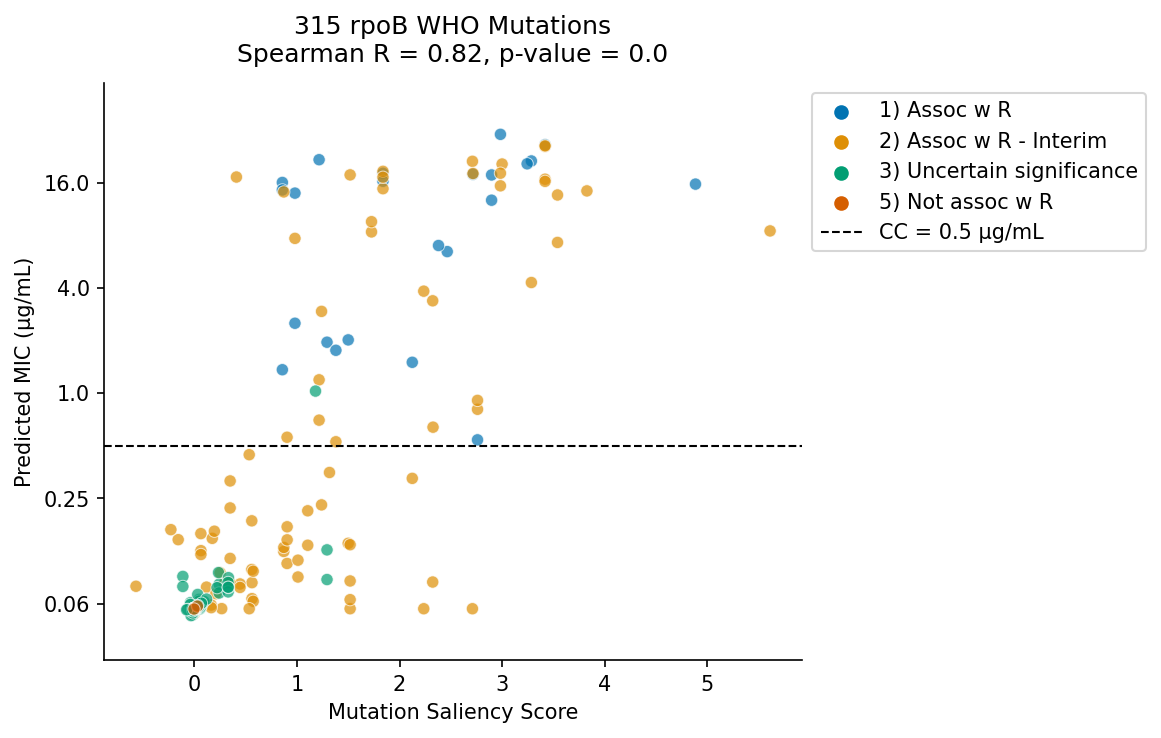

In [118]:
# only plot sites with at least one significant saliency score because the others are not reliable
saliency_scatter_plot(df_RIF_saliency_plot.query("Max_Sig == 1 | Min_Sig == 1"), 
                      corr_type="Spearman", 
                      #saveName="Rifampicin/insilico_mutagenesis/MIC_saliency_scatter.png"
                     )

In [ ]:
# R-associated mutations predicted susceptible
df_rif_saliency_plot.query("confidence=='1) Assoc w R' & log_MIC < -1")

,log_MIC,mutation,confidence,genome_index,MIC,gene,POS,REF,ALT,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020,saliency_score
5,-1.675691,rpoB_p.His445Asn,1) Assoc w R,761139,0.313016,rpoB,761139,C,A,rpoBC,761139.0,5.481325,-2.495282,1.0,1.0,1,0,0,5.481325


In [124]:
# uncertain mutation that predicts resistance
thresh = np.log(0.5)
df_rif_saliency_plot.query("log_MIC > @thresh and confidence.str.contains('3')")

,log_MIC,mutation,confidence,genome_index,gene,POS,REF,ALT,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020,saliency_score
699,0.039532,rpoB_p.Ile491Tyr,3) Uncertain significance,"761277,761278",rpoB,761277,A,T,rpoBC,761277.0,2.801617,-0.215066,1.0,1.0,1,0,0,1.181174


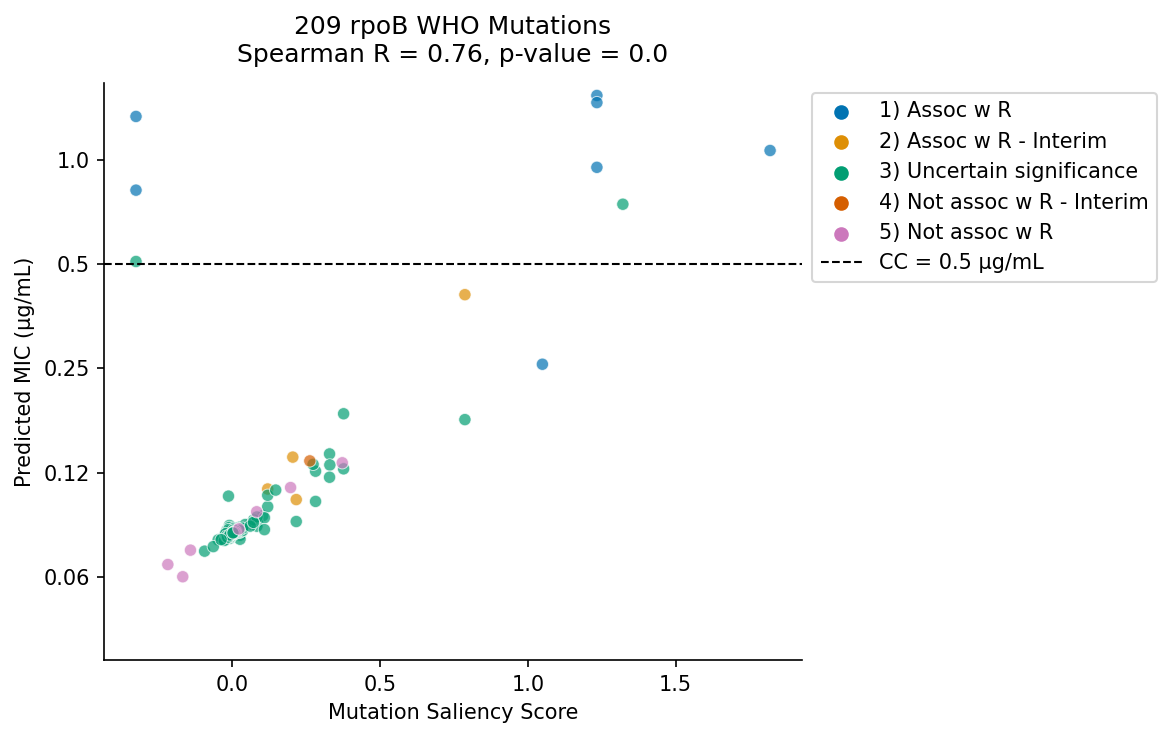

In [120]:
# only plot sites with at least one significant saliency score because the others are not reliable
saliency_scatter_plot(df_MXF_saliency_plot.query("Max_Sig == 1 | Min_Sig == 1"), 
                      corr_type="Spearman", 
                      #saveName="Rifampicin/insilico_mutagenesis/MIC_saliency_scatter.png"
                     )

In [125]:
df_MXF_saliency_plot.query("saliency_score < 0 & log_MIC > @thresh")

,log_MIC,mutation,confidence,genome_index,gene,POS,REF,ALT,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020,saliency_score
1,0.417849,gyrA_p.Asp94Gly,1) Assoc w R,7582,gyrA,7582,A,G,gyrBA,7582.0,1.247441,-0.325217,0.0,1.0,1,0,0,-0.325217
3,-0.289461,gyrA_p.Asp94Ala,1) Assoc w R,7582,gyrA,7582,A,C,gyrBA,7582.0,1.247441,-0.325217,0.0,1.0,1,0,0,-0.325217


# Further Investigation of the Group 2 Mutations with Low Saliency Scores or Low Predicted MICs

### Hypothesis: Low saliency = not in the training dataset.
### Low predicted MIC: IDK!


761134 is the only (1/11) category 1 site without a significant positive saliency score in the RIF CNN

In [231]:
plot_df.query("dataset==1 & MIC_pred < @thresh & saliency_score > 2 & confidence.str.contains('|'.join(['1', '2']))")

,mutation,MIC_pred,genome_index,WHO_genome_index,confidence,POS,gene,variant,REF,ALT,Gene,Max,Min,Mean,Max_Sig,Min_Sig,REF_len,ALT_len,saliency_score,dataset
10,rpoB_p.Gln432His,-1.063436,761102,761102,2) Assoc w R - Interim,761102,rpoB,p.Gln432His,A,T,rpoBC,2.071347,0.000000,0.001046,1.0,0.0,1,1,2.071347,1
14,rpoB_p.His445Asn,-1.661120,761139,761139,1) Assoc w R,761139,rpoB,p.His445Asn,C,A,rpoBC,3.437077,0.000000,0.103309,1.0,0.0,1,1,3.437077,1
29,rpoB_p.Asp435Ala,-0.963358,761110,761110,2) Assoc w R - Interim,761110,rpoB,p.Asp435Ala,A,C,rpoBC,4.191139,0.000000,0.223620,1.0,0.0,1,1,4.191139,1
33,rpoB_p.Asp435His,-1.884073,761109,761109,2) Assoc w R - Interim,761109,rpoB,p.Asp435His,G,C,rpoBC,2.973908,-0.722329,0.037628,1.0,1.0,1,1,2.973908,1
47,rpoB_p.Leu430Arg,-1.703787,761095,761095,2) Assoc w R - Interim,761095,rpoB,p.Leu430Arg,T,G,rpoBC,2.659062,0.000000,0.015638,1.0,0.0,1,1,2.659062,1


In [232]:
search_df = plot_df.query("MIC_pred < @thresh & saliency_score > 2 & confidence.str.contains('|'.join(['1', '2']))")
print(search_df.shape)
search_df = search_df[(search_df["REF"].apply(lambda x: len(x) == 1)) & (search_df["ALT"].apply(lambda x: len(x) == 1))]
print(search_df.shape)

(7, 20)
(6, 20)


In [233]:
scores = sparse.load_npz("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC/saliency/quant/genetic_scores_unpooled_nuc.npy.npz").todense()
# num_samples x 5 nucleotides x longest_locus x num_loci
scores.shape

(7480, 5, 7814, 1)

In [234]:
rif_rpoBC_df = rif_rpoBC_df.reset_index(drop=True)
BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}

def plot_nuc_scores_single_pos(pos):
    
    search_idx = rif_rpoBC_df.query("Pos==@pos").index.values[0]
    ref = plot_df.query("POS==@pos")["REF"].unique()[0]

    if rif_rpoBC_df.query("Pos==@pos")["Max_Sig"].values[0] == 1:
        scores_by_nuc = dict(zip(BASE_TO_COLUMN.keys(), np.max(scores[:, :, search_idx, :], axis=0).flatten()))

    elif rif_rpoBC_df.query("Pos==@pos")["Min_Sig"].values[0] == 1:
        scores_by_nuc = dict(zip(BASE_TO_COLUMN.keys(), np.min(scores[:, :, search_idx, :], axis=0).flatten()))

    else:
        raise ValueError(f"{pos} does not have a significant score!")

    plot_df_single_site = plot_df.query("POS==@pos")[["mutation", "MIC_pred", "ALT"]]
    y_col = "MIC_pred"
    
#     plot_df_single_site = rpoBC_seqDF[["Isolate", pos]]
#     plot_df_single_site = plot_df_single_site.merge(df_rif[["ROLLINGDB_ID", "RIF_midpoint"]], left_on="Isolate", right_on="ROLLINGDB_ID", how="inner")

#     plot_df_single_site = pd.DataFrame(plot_df_single_site.groupby(pos)["RIF_midpoint"].mean()).reset_index().rename(columns={pos:"ALT"})
    # y_col = "RIF_midpoint"

    plot_df_single_site["saliency"] = plot_df_single_site["ALT"].map(scores_by_nuc)
    print(plot_df_single_site.sort_values("MIC_pred"))

    fig, ax = plt.subplots(figsize=(3, 2))
    sns.scatterplot(data=plot_df_single_site, x="saliency", y=y_col, ax=ax)
    plt.title(f"POS: {pos}, REF nucleotide: {ref}")

    for _, row in plot_df_single_site.iterrows():
        if row["ALT"] != ref:
            plt.text(row["saliency"]+0.05, row[y_col], row["ALT"])

    sns.despine()
    plt.show()

In [ ]:
pos = 761110
search_idx = rif_rpoBC_df.query("Pos==@pos").index.values[0]
ref = plot_df.query("POS==@pos")["REF"].unique()[0]
ref

'A'

In [ ]:
scores.shape

(7480, 5, 7814, 1)

In [ ]:
# this is what we store / plot
np.max(np.sum(scores, axis=1), axis=0).shape

(7814, 1)

In [ ]:
np.squeeze(np.max(scores, axis=0)).shape

(5, 7814)

In [ ]:
np.squeeze(np.max(scores, axis=0))

array([[0.0000000e+00, 6.3485255e-05, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 1.9839880e-04, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [ ]:
np.squeeze(X_h37rv).shape

(5, 7814)

In [ ]:
plt.plot()

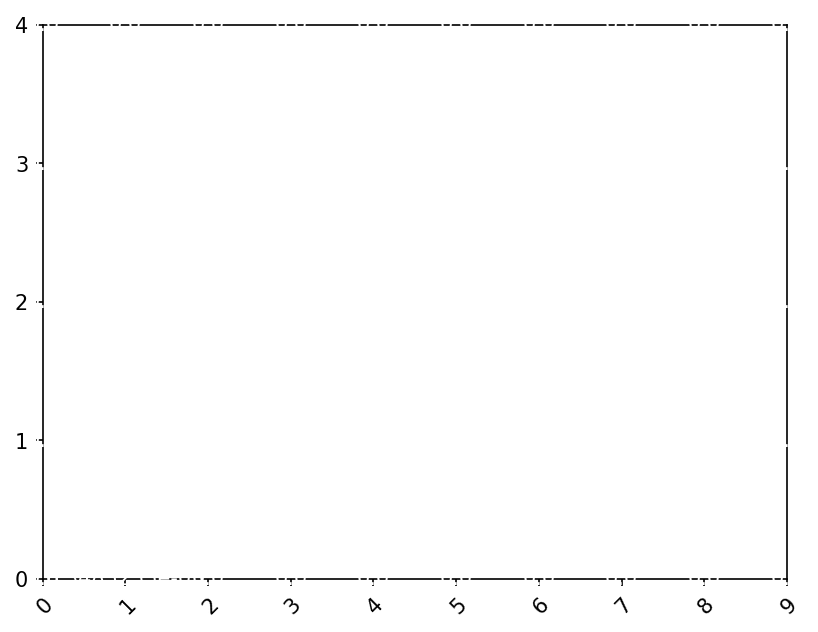

In [120]:
nucleotides = BASE_TO_COLUMN.keys()
positions = np.arange(1, 7814+1)[:10]

max_scores = np.squeeze(np.max(scores, axis=0))

fig, ax = plt.subplots()
# im = ax.imshow(max_scores)

# Show all ticks and label them with the respective list entries
ax.set_xticks(np.arange(len(positions)))
ax.set_yticks(np.arange(len(nucleotides)))

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

# Loop over data dimensions and create text annotations.
for i in range(len(nucleotides)):
    for j in range(len(positions)):
        text = ax.text(j, i, max_scores[i, j],
                       ha="center", va="center", color="w")

In [236]:
output_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC"
X_h37rv = sparse.load_npz(os.path.join(output_path, 'pkl_sparse_ref.npz')).todense()
X_h37rv.shape

(1, 5, 7814, 1)

In [237]:
# check that the base to column indexing is correct
for idx in range(X_h37rv.shape[2]):
    
    pos = rif_rpoBC_df.loc[idx, "Pos"]
    ref = rpoBC_seqDF.loc["MT_H37Rv", pos]
    
    if not BASE_TO_COLUMN[ref] == np.where(np.squeeze(X_h37rv)[:, idx]==1)[0][0]:
        print(idx)

In [239]:
search_df

,mutation,MIC_pred,genome_index,WHO_genome_index,confidence,POS,gene,variant,REF,ALT,Gene,Max,Min,Mean,Max_Sig,Min_Sig,REF_len,ALT_len,saliency_score,dataset
10,rpoB_p.Gln432His,-1.063436,761102,761102,2) Assoc w R - Interim,761102,rpoB,p.Gln432His,A,T,rpoBC,2.071347,0.000000,0.001046,1.0,0.0,1,1,2.071347,1
14,rpoB_p.His445Asn,-1.661120,761139,761139,1) Assoc w R,761139,rpoB,p.His445Asn,C,A,rpoBC,3.437077,0.000000,0.103309,1.0,0.0,1,1,3.437077,1
29,rpoB_p.Asp435Ala,-0.963358,761110,761110,2) Assoc w R - Interim,761110,rpoB,p.Asp435Ala,A,C,rpoBC,4.191139,0.000000,0.223620,1.0,0.0,1,1,4.191139,1
33,rpoB_p.Asp435His,-1.884073,761109,761109,2) Assoc w R - Interim,761109,rpoB,p.Asp435His,G,C,rpoBC,2.973908,-0.722329,0.037628,1.0,1.0,1,1,2.973908,1
47,rpoB_p.Leu430Arg,-1.703787,761095,761095,2) Assoc w R - Interim,761095,rpoB,p.Leu430Arg,T,G,rpoBC,2.659062,0.000000,0.015638,1.0,0.0,1,1,2.659062,1
49,rpoB_p.Leu452Gln,-1.203364,761161,761161,2) Assoc w R - Interim,761161,rpoB,p.Leu452Gln,T,A,rpoBC,2.145033,0.000000,0.017396,1.0,0.0,1,1,2.145033,0


In [248]:
rpoB_ALL_VCF.query("POS==761139").sort_values("mutation")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
16,RIF,761139,1) Assoc w R,rpoB_p.His445Asn,761139,rpoB,p.His445Asn,C,A,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
18,RIF,761139,1) Assoc w R,rpoB_p.His445Asp,761139,rpoB,p.His445Asp,C,G,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
19,RIF,761139,1) Assoc w R,rpoB_p.His445Cys,761139,rpoB,p.His445Cys,C,T,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
21,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Gly,761139,rpoB,p.His445Gly,C,G,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
23,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Phe,761139,rpoB,p.His445Phe,C,T,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
20,RIF,761139,1) Assoc w R,rpoB_p.His445Ser,761139,rpoB,p.His445Ser,C,A,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
22,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Thr,761139,rpoB,p.His445Thr,C,A,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
17,RIF,761139,1) Assoc w R,rpoB_p.His445Tyr,761139,rpoB,p.His445Tyr,C,T,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1


In [252]:
rpoB_ALL.query("mutation=='rpoB_p.His445Ser'")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Pos,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
20,RIF,761139,1) Assoc w R,rpoB_p.His445Ser,761139,rpoB,p.His445Ser,C,A,rpoBC,761139,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
50,RIF,761140,1) Assoc w R,rpoB_p.His445Ser,761140,rpoB,p.His445Ser,A,G,rpoBC,761140,4.169374,0.0,0.040140,1.0,0.0,1,0,1,1


In [253]:
rpoB_ALL.query("mutation=='rpoB_p.His445Thr'")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Pos,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
22,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Thr,761139,rpoB,p.His445Thr,C,A,rpoBC,761139,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
53,RIF,761140,2) Assoc w R - Interim,rpoB_p.His445Thr,761140,rpoB,p.His445Thr,A,C,rpoBC,761140,4.169374,0.0,0.040140,1.0,0.0,1,0,1,1


In [254]:
rpoB_ALL.query("mutation=='rpoB_p.His445Cys'")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Pos,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
19,RIF,761139,1) Assoc w R,rpoB_p.His445Cys,761139,rpoB,p.His445Cys,C,T,rpoBC,761139,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
49,RIF,761140,1) Assoc w R,rpoB_p.His445Cys,761140,rpoB,p.His445Cys,A,G,rpoBC,761140,4.169374,0.0,0.040140,1.0,0.0,1,0,1,1


In [255]:
rpoB_ALL.query("mutation=='rpoB_p.His445Gly'")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Pos,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
21,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Gly,761139,rpoB,p.His445Gly,C,G,rpoBC,761139,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
52,RIF,761140,2) Assoc w R - Interim,rpoB_p.His445Gly,761140,rpoB,p.His445Gly,A,G,rpoBC,761140,4.169374,0.0,0.040140,1.0,0.0,1,0,1,1


            mutation  MIC_pred ALT  saliency
14  rpoB_p.His445Asn -1.661120   A  0.000000
20  rpoB_p.His445Thr  0.403495   A  0.000000
18  rpoB_p.His445Ser  0.857502   A  0.000000
19  rpoB_p.His445Gly  1.638188   G  1.461783
21  rpoB_p.His445Phe  1.679750   T  1.677972
17  rpoB_p.His445Cys  1.761852   T  1.677972
16  rpoB_p.His445Asp  1.784891   G  1.461783
15  rpoB_p.His445Tyr  1.877036   T  1.677972


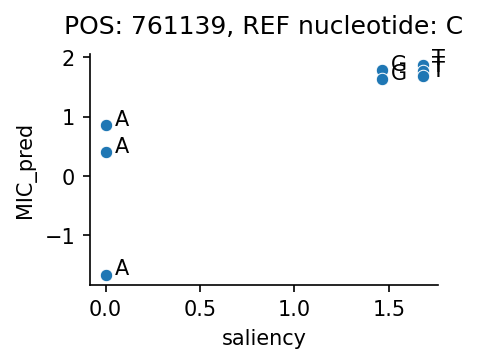

            mutation  MIC_pred ALT  saliency
29  rpoB_p.Asp435Ala -0.963358   C  0.000000
30  rpoB_p.Asp435Gly -0.617019   G  0.000000
31  rpoB_p.Asp435Leu  1.278635   T  1.948339
28  rpoB_p.Asp435Phe  1.684420   T  1.948339
27  rpoB_p.Asp435Val  1.743449   T  1.948339


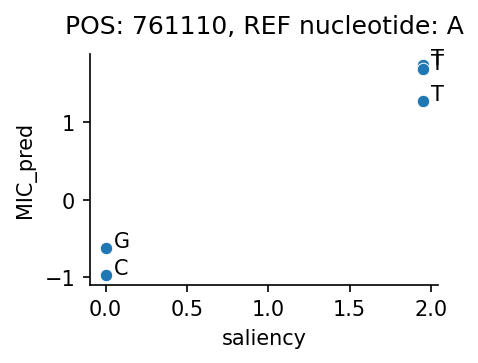

            mutation  MIC_pred ALT  saliency
33  rpoB_p.Asp435His -1.884073   C  0.000000
32  rpoB_p.Asp435Tyr  0.021469   T  1.823904


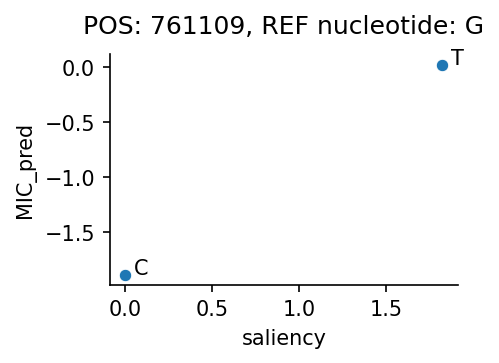

            mutation  MIC_pred ALT  saliency
47  rpoB_p.Leu430Arg -1.703787   G  0.135575
46  rpoB_p.Leu430Pro -0.011871   C  1.299761


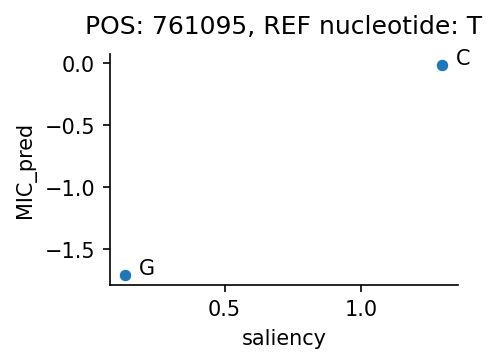

            mutation  MIC_pred ALT  saliency
49  rpoB_p.Leu452Gln -1.203364   A  0.000000
48  rpoB_p.Leu452Pro  0.146495   C  0.848814


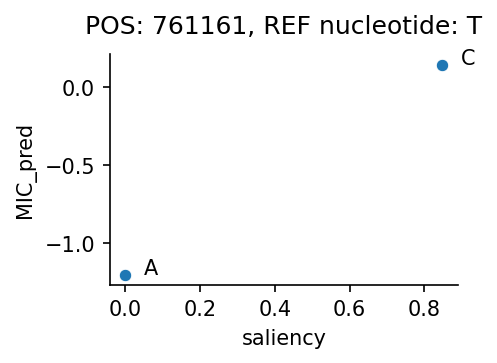

In [242]:
for pos in search_df.POS.unique():
    
    # this one has indels, skip for simplicity rn
    if pos != 761102:
        plot_nuc_scores_single_pos(pos)